In [16]:
import pandas as pd
import numpy as np
import sklearn
import sklearn.metrics
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import root_mean_squared_error, mean_squared_error, accuracy_score, roc_auc_score, mean_absolute_error, f1_score
import sklearn.model_selection
from typing import Tuple, List, Any, Dict, Union
from lightgbm import LGBMRegressor, LGBMClassifier
import lightgbm as lgb
import optuna
import pickle

import warnings, os
import mysql.connector as mysql
warnings.filterwarnings('ignore')
username = os.environ['MYSQL_user']
password = os.environ['MYSQL_password']
DB = mysql.connect(host = "localhost", user = username, passwd = password, database = "AIRBNB")
cursor = DB.cursor(buffered=True)
SEED = 17
compare_metric_name = 'RMSE'

## Utils

In [2]:
def read_table_from_db(table_name):
    df = pd.read_sql(f'SELECT * FROM {table_name}', con=DB)
    return df

In [3]:
def perform_cv(X: pd.DataFrame, y: pd.Series, algorithm: Any, cv: sklearn.model_selection = KFold(n_splits=5, shuffle=True, random_state=SEED), metric: sklearn.metrics = root_mean_squared_error) -> Tuple[List[float], List[float]]:
    """
    Perform cross-validation and return list of scores
    
    Args:
        X (pd.DataFrame): input data
        y (pd.Series): target data
        algorithm (Any): algorithm to use for training and prediction
        cv (sklearn.model_selection, default=KFold(n_splits=5, shuffle=True, random_state=SEED)): cross-validation strategy
        metric (sklearn.metrics, default=root_mean_squared_error): metric to use for evaluation
    
    Returns:
        Tuple[List[float], List[float]]: Tuple of lists of train and validation scores
    """
    train_scores, validation_scores = [], []
    for train_idx, val_idx in cv.split(X, y):
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
        algorithm.fit(X_train, y_train)
        y_train_pred = algorithm.predict(X_train)
        y_val_pred = algorithm.predict(X_val)
        train_scores.append(metric(y_train, y_train_pred))
        validation_scores.append(metric(y_val, y_val_pred))
    return train_scores, validation_scores

def evaluation(X_train: pd.DataFrame, y_train: pd.Series, X_test: pd.DataFrame, y_test: pd.Series, algorithm: Any, metric: sklearn.metrics = root_mean_squared_error) -> Tuple[float, float, np.ndarray]:
    """
    Train the algorithm on the train data and evaluate on the train and test data
    
    Args:
        X_train (pd.DataFrame): input train data
        y_train (pd.Series): target train data
        X_test (pd.DataFrame): input test data
        y_test (pd.Series): target test data
        algorithm (Any): algorithm to use for training and prediction
        metric (sklearn.metrics, default=root_mean_squared_error): metric to use for evaluation
    
    Returns:
        Tuple[float, float, np.ndarray]: train_score, test_score, predictions on test data
    """
    algorithm.fit(X_train, y_train)
    y_train_pred = algorithm.predict(X_train)
    y_test_pred = algorithm.predict(X_test)
    train_results = metric(y_train, y_train_pred)
    test_results = metric(y_test, y_test_pred)
    return train_results, test_results, y_test_pred

# Load dataset

In [4]:
data = read_table_from_db('airbnb_data')
target_feature = 'log_price'
independent_features = data.columns.drop(target_feature)
data

,host_is_superhost,host_has_profile_pic,host_identity_verified,accommodates,bedrooms,beds,minimum_nights,maximum_nights,availability_30,availability_365,...,number_of_education_institutions_within_100m,distance_to_nearest_cultural_institution_m,number_of_cultural_institutions_within_100m,distance_to_nearest_recreation_point_m,number_of_recreation_points_within_100m,distance_to_nearest_religious_institution_m,number_of_religious_institutions_within_100m,distance_to_nearest_health_institution_m,number_of_health_institutions_within_100m,distance_to_nearest_main_attraction_m
0,0,1,1,1.0,0.0,1.0,30.0,1125.0,0.0,248.0,...,0,264.899,0,74.9974,1,113.3110,0,748.997,0,497.315
1,0,1,1,2.0,1.0,1.0,30.0,150.0,0.0,233.0,...,1,114.917,0,157.0960,0,143.3380,0,798.512,0,5687.510
2,0,1,1,4.0,2.0,2.0,30.0,730.0,0.0,121.0,...,1,419.009,0,375.3300,0,201.4310,0,607.539,0,5139.470
3,1,1,1,3.0,2.0,1.0,30.0,730.0,0.0,157.0,...,1,441.078,0,122.0370,0,489.0130,0,867.072,0,5022.830
4,0,1,1,1.0,1.0,1.0,30.0,180.0,30.0,365.0,...,0,571.057,0,108.9370,0,157.2840,0,262.918,0,2800.150
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32193,0,0,1,1.0,1.0,1.0,30.0,365.0,30.0,365.0,...,1,545.044,0,135.5650,0,91.0919,1,270.468,0,2923.900
32194,0,1,1,8.0,3.0,3.0,30.0,365.0,24.0,359.0,...,0,235.442,0,371.3940,0,144.9710,0,1375.180,0,705.223
32195,1,1,1,1.0,1.0,1.0,30.0,190.0,30.0,364.0,...,0,287.143,0,119.7920,0,123.8000,0,518.209,0,8220.670
32196,0,0,1,1.0,1.0,1.0,30.0,365.0,29.0,362.0,...,0,134.143,0,129.3570,0,326.8640,0,263.809,0,1529.340


## Split dataset

In [5]:
train_data, test_data = train_test_split(data, test_size=0.2, random_state=SEED)

## Base model

In [12]:
compare_metric_name = 'MAE'
model = LGBMRegressor(random_state=SEED, verbose=-1)
train_scores, validation_scores = perform_cv(train_data[independent_features], train_data[target_feature], model, cv=KFold(n_splits=5, shuffle=True, random_state=SEED), metric=mean_absolute_error)
print(f"Train {compare_metric_name}: {np.mean(train_scores):.4f} +- {np.std(train_scores):.4f}")
print(f"Validation {compare_metric_name}: {np.mean(validation_scores):.4f} +- {np.std(validation_scores):.4f}")

Train MAE: 0.3850 +- 0.0013
Validation MAE: 0.4303 +- 0.0052


In [13]:
compare_metric_name = 'MAE'
data["price"] = np.exp(data["log_price"])
target_feature = 'price'
train_data, test_data = train_test_split(data, test_size=0.2, random_state=SEED)
model = LGBMRegressor(random_state=SEED, verbose=-1)
train_scores, validation_scores = perform_cv(train_data[independent_features], train_data[target_feature], model, cv=KFold(n_splits=5, shuffle=True, random_state=SEED), metric=mean_absolute_error)
print(f"Train {compare_metric_name}: {np.mean(train_scores):.4f} +- {np.std(train_scores):.4f}")
print(f"Validation {compare_metric_name}: {np.mean(validation_scores):.4f} +- {np.std(validation_scores):.4f}")

Train MAE: 48.0109 +- 0.3697
Validation MAE: 56.5803 +- 0.9440


In [19]:
# very cheap: 10-50
# cheap: 50-100
# moderate: 100-200
# expensive: 200-500
# very expensive: 500-10000
compare_metric_name = 'Accuracy'
data["price_bins"] = pd.cut(data["price"], bins=[0, 50, 100, 200, 500, 10000], labels=False)
target_feature = 'price_bins'
train_data, test_data = train_test_split(data, test_size=0.2, random_state=SEED)
model = LGBMClassifier(random_state=SEED, verbose=-1, objective='multiclass')
train_scores, validation_scores = perform_cv(train_data[independent_features], train_data[target_feature], model, cv=KFold(n_splits=5, shuffle=True, random_state=SEED), metric=accuracy_score)
print(f"Train {compare_metric_name}: {np.mean(train_scores):.4f} +- {np.std(train_scores):.4f}")
print(f"Validation {compare_metric_name}: {np.mean(validation_scores):.4f} +- {np.std(validation_scores):.4f}")

Train Accuracy: 0.8581 +- 0.0013
Validation Accuracy: 0.6731 +- 0.0035


In [ ]:
model = LGBMClassifier(random_state=SEED, verbose=-1, objective='multiclass')
X_train, y_train = train_data[independent_features], train_data[target_feature]
X_test, y_test = test_data[independent_features], test_data[target_feature]
model.fit(X_train, y_train)
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)
print('Train classification report')
print(sklearn.metrics.classification_report(y_train, y_train_pred))
print('Test classification report')
print(sklearn.metrics.classification_report(y_test, y_test_pred))

Train classification report
              precision    recall  f1-score   support

           0       0.95      0.87      0.91      2512
           1       0.82      0.86      0.84      6533
           2       0.79      0.82      0.80      8365
           3       0.84      0.82      0.83      6811
           4       0.96      0.80      0.87      1537

    accuracy                           0.83     25758
   macro avg       0.87      0.83      0.85     25758
weighted avg       0.84      0.83      0.83     25758

Test classification report
              precision    recall  f1-score   support

           0       0.81      0.63      0.71       601
           1       0.66      0.73      0.69      1611
           2       0.65      0.67      0.66      2142
           3       0.67      0.68      0.68      1679
           4       0.72      0.46      0.56       407

    accuracy                           0.67      6440
   macro avg       0.70      0.64      0.66      6440
weighted avg       0.6

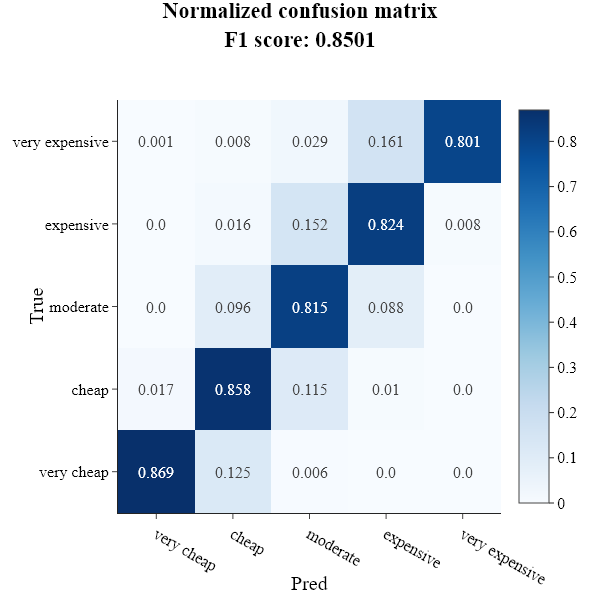

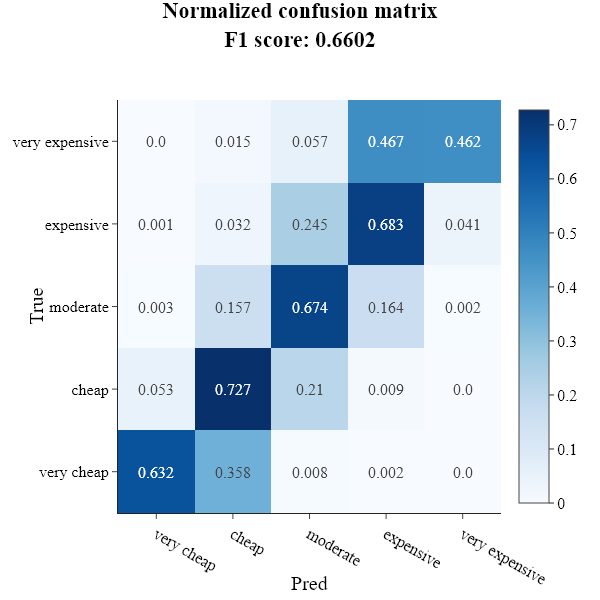

In [23]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
)
import plotly.graph_objects as go
import numpy as np

def multilabel_conf_matrix(y_true, y_pred, labels, normalize=False):
    if normalize == True:
        CM = confusion_matrix(y_true, y_pred, normalize="true")
        title = "Normalized confusion matrix"
    else:
        CM = confusion_matrix(y_true, y_pred, normalize=None)
        title = "Confusion matrix"
    x = [str(i) for i in labels]
    fig = go.Figure()
    z_text = np.round(CM, 3).astype(str)
    fig.add_trace(
        go.Heatmap(
            z=CM,
            x=x,
            y=x,
            colorscale="blues",
            showscale=True,
            text=z_text,
            texttemplate="%{text}",
        )
    )
    fig.update_layout(
        template="simple_white",
        width=600,
        height=600,
        showlegend=False,
        font=dict(family="Times New Roman", size=16, color="Black"),
        title_text="<b>{}<br>F1 score: {}<b>".format(
            title,
            np.round(f1_score(y_true, y_pred, average="macro", zero_division=1.0), 4),
        ),
        title_x=0.5,
        title_y=0.97,
    )
    fig.add_annotation(
        dict(
            font=dict(family="Times New Roman", size=20, color="Black"),
            x=-0.25,
            y=0.5,
            showarrow=False,
            text="True",
            textangle=-90,
            xref="paper",
            yref="paper",
        )
    )
    fig.add_annotation(
        dict(
            font=dict(family="Times New Roman", size=20, color="Black"),
            x=0.5,
            y=-0.2,
            showarrow=False,
            text="Pred",
            xref="paper",
            yref="paper",
        )
    )
    fig.show("png")

labels_names = ["very cheap", "cheap", "moderate", "expensive", "very expensive"]
multilabel_conf_matrix(y_train, y_train_pred, labels_names, normalize=True)
multilabel_conf_matrix(y_test, y_test_pred, labels_names, normalize=True)